/vftmp/Remi.Pages/pid179295/ipykernel_189922/2225469258.py:154: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds_in = xr.open_dataset(INPUT_OBCS, decode_times=True)


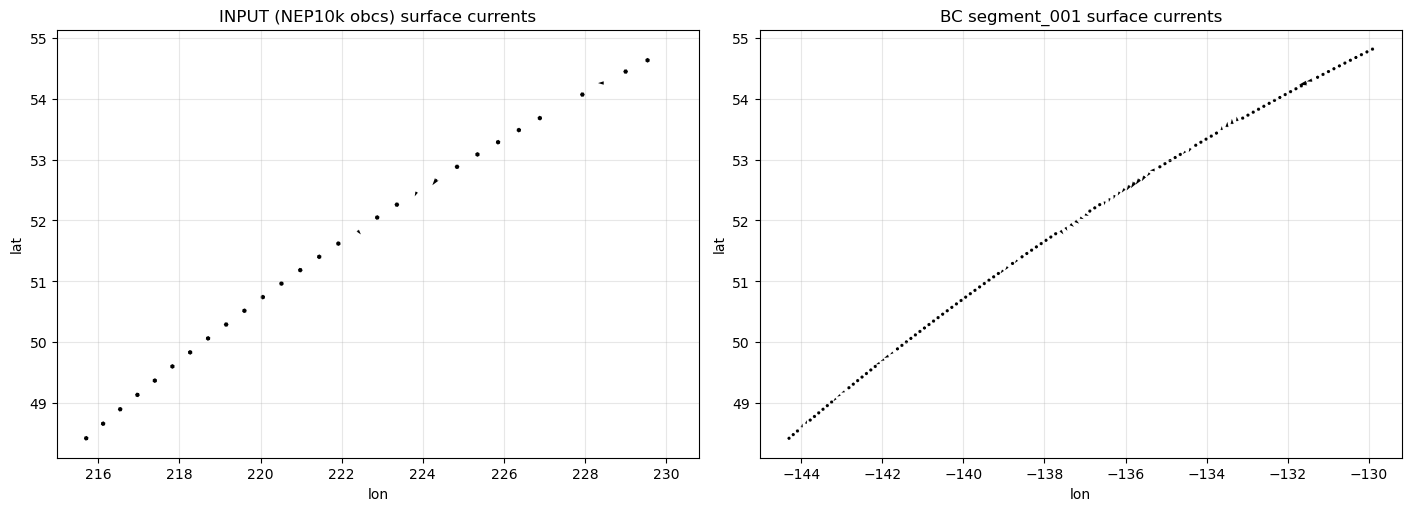

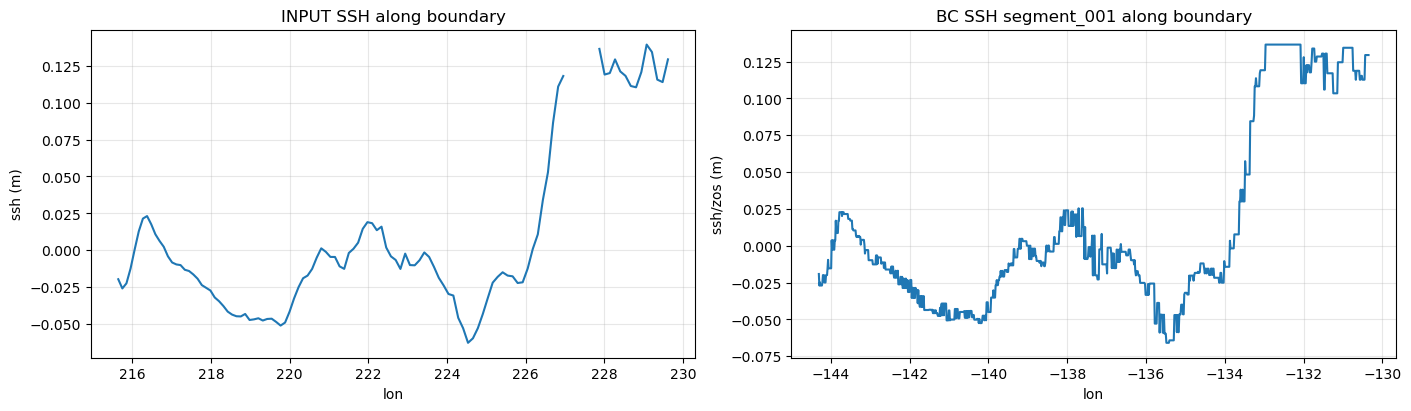

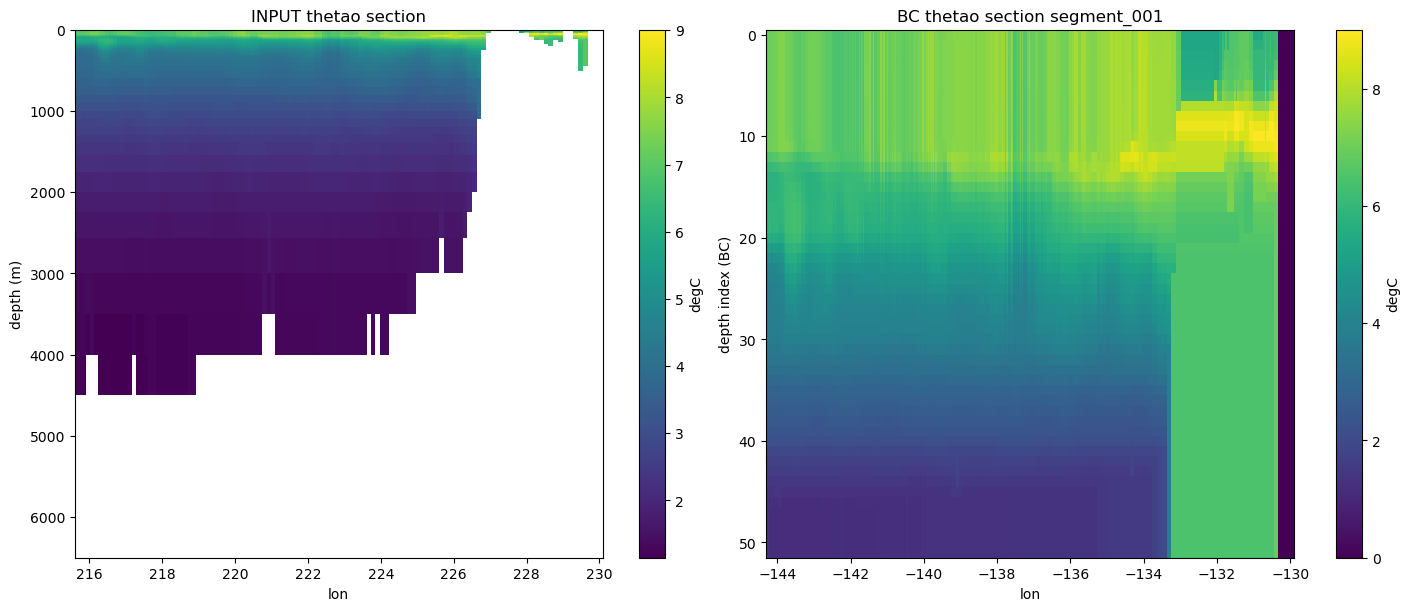

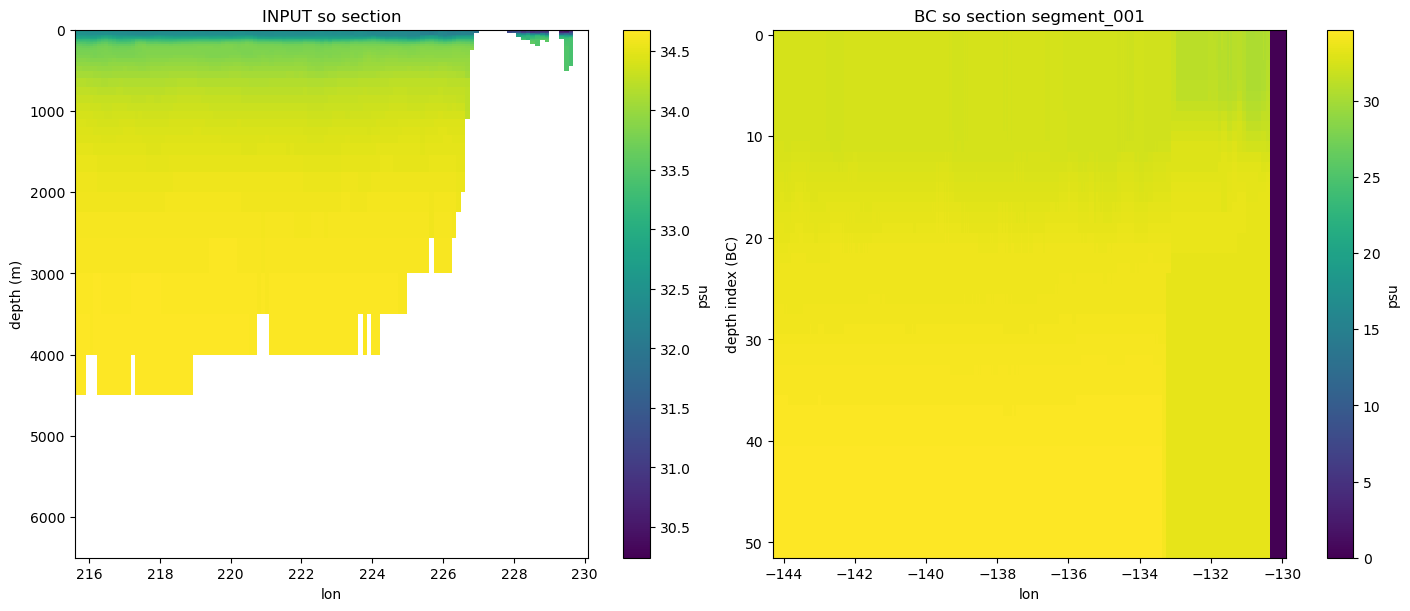

In [2]:
# ============================================================
# NEP10k -> GOA2.5k OBC visual comparison (NO interpolation)
# INPUT (NEP10k obcs file) vs BC (segment_001 files)
# - surface quiver (u,v)
# - SSH line
# - T/S vertical section
#
# Remi-style: minimal deps, clean functions, explicit params
# ============================================================

import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt


# ---------------------------
# USER PARAMS (edit paths)
# ---------------------------
INPUT_OBCS = "/work/Remi.Pages/GOA2p5k/HINDCAST/19930101.goa_obcs_east.nc"     # NEP10k input
BC_U   = "uv_001_1993.nc"                   # or your u bc file
BC_T   = "thetao_001_1993.nc"
BC_S   = "so_001_1993.nc"
BC_SSH = "zos_001_1993.nc"

SEG = "001"  # segment id string used in BC variable names

# Pick a time to compare (either by index, or exact datetime)
TIME_INDEX = 0  # easiest
# Or use e.g. TIME_SEL = "1993-01-15 00:00:00"
TIME_SEL = None

# Depth level for currents (index in z_l / nz)
Z_INDEX_FOR_UV = 0  # surface-ish

# Subsample arrows along boundary
QUIVER_STEP_INPUT = 4
QUIVER_STEP_BC    = 8




# ---------------------------
# helpers
# ---------------------------
def _to_nan(da):
    """Convert common FillValue / missing_value conventions to NaN."""
    if da is None:
        return None
    fv = da.attrs.get("_FillValue", None)
    mv = da.attrs.get("missing_value", None)
    out = da
    for bad in [fv, mv, 1e20, 1.e20, 9.96921e36]:
        if bad is None:
            continue
        out = out.where(out != bad)
    return out


def _find_var(ds, candidates):
    """Return first variable name in ds.variables matching candidates."""
    for c in candidates:
        if c in ds.variables:
            return c
    return None


def _decode_time(ds):
    """Decode time to datetime64 if possible; otherwise leave as is."""
    # Use xarray decode_times if it works; fallback keeps numeric time
    try:
        return xr.open_dataset(ds.encoding["source"], decode_times=True)
    except Exception:
        return ds


def _select_time(ds, time_sel=None, time_index=0):
    """Return ds sliced at a single time."""
    if "time" not in ds.dims and "time" not in ds.coords:
        return ds
    if time_sel is not None:
        # nearest time match
        t = np.datetime64(pd.to_datetime(time_sel))
        return ds.sel(time=t, method="nearest")
    return ds.isel(time=time_index)


def _mean_over_2rows_if_present(da, ydim_candidates=("jh_sub02", "jh_sub04")):
    """
    INPUT files often have 2 rows along boundary (jh_* = 2).
    Average over that dimension to get 1D along-boundary.
    """
    for yd in ydim_candidates:
        if yd in da.dims and da.sizes.get(yd, 1) == 2:
            return da.mean(yd)
    return da


def _squeeze_to_1d(da):
    """Squeeze singleton dims."""
    return da.squeeze(drop=True)


def _get_input_uv_ts_ssh(ds_in):
    # variables in INPUT
    u_name = _find_var(ds_in, ["uo", "u", "u_ocean", "uvel", "u"])
    v_name = _find_var(ds_in, ["vo", "v", "v_ocean", "vvel", "v"])

    t_name = _find_var(ds_in, ["thetao", "temp", "tos", "t"])
    s_name = _find_var(ds_in, ["so", "salt", "s"])

    ssh_name = _find_var(ds_in, ["ssh", "zos", "eta", "zeta"])

    # coords
    lonu = _find_var(ds_in, ["geolon_u", "lon_u", "lonu"])
    latu = _find_var(ds_in, ["geolat_u", "lat_u", "latu"])
    lonv = _find_var(ds_in, ["geolon_v", "lon_v", "lonv"])
    latv = _find_var(ds_in, ["geolat_v", "lat_v", "latv"])

    lont = _find_var(ds_in, ["geolon", "lon", "geolon_t"])
    latt = _find_var(ds_in, ["geolat", "lat", "geolat_t"])

    return dict(
        u=u_name, v=v_name, t=t_name, s=s_name, ssh=ssh_name,
        lonu=lonu, latu=latu, lonv=lonv, latv=latv, lont=lont, latt=latt
    )


def _get_bc_vars(ds_bc, seg="001"):
    # BC variable names like thetao_segment_001
    def segname(base): 
        return f"{base}_segment_{seg}"

    u_name   = _find_var(ds_bc, [segname("uo"), segname("u"), segname("uvel"), "uo_segment_001", "u_segment_001"])
    v_name   = _find_var(ds_bc, [segname("vo"), segname("v"), segname("vvel"), "vo_segment_001", "v_segment_001"])
    t_name   = _find_var(ds_bc, [segname("thetao"), segname("temp"), "thetao_segment_001"])
    s_name   = _find_var(ds_bc, [segname("so"), segname("salt"), "so_segment_001"])
    ssh_name = _find_var(ds_bc, [segname("zos"), segname("ssh"), "zos_segment_001", "ssh_segment_001"])

    lon = _find_var(ds_bc, [f"lon_segment_{seg}", "lon_segment_001", "lon"])
    lat = _find_var(ds_bc, [f"lat_segment_{seg}", "lat_segment_001", "lat"])

    return dict(u=u_name, v=v_name, t=t_name, s=s_name, ssh=ssh_name, lon=lon, lat=lat)


def _maybe_open(path):
    return xr.open_dataset(path, decode_times=True)


# ---------------------------
# open datasets
# ---------------------------
ds_in = xr.open_dataset(INPUT_OBCS, decode_times=True)
ds_u  = _maybe_open(BC_U)
ds_v  = _maybe_open(BC_U)
ds_t  = _maybe_open(BC_T)
ds_s  = _maybe_open(BC_S)
ds_z  = _maybe_open(BC_SSH)

# re-select one time everywhere (nearest if TIME_SEL set)
ds_in1 = _select_time(ds_in, time_sel=TIME_SEL, time_index=TIME_INDEX)
ds_u1  = _select_time(ds_u,  time_sel=TIME_SEL, time_index=TIME_INDEX)
ds_v1  = _select_time(ds_v,  time_sel=TIME_SEL, time_index=TIME_INDEX)
ds_t1  = _select_time(ds_t,  time_sel=TIME_SEL, time_index=TIME_INDEX)
ds_s1  = _select_time(ds_s,  time_sel=TIME_SEL, time_index=TIME_INDEX)
ds_z1  = _select_time(ds_z,  time_sel=TIME_SEL, time_index=TIME_INDEX)

# ---------------------------
# extract INPUT
# ---------------------------
vin = _get_input_uv_ts_ssh(ds_in1)

U_in = _to_nan(ds_in1[vin["u"]]).isel(z_l=Z_INDEX_FOR_UV)
V_in = _to_nan(ds_in1[vin["v"]]).isel(z_l=Z_INDEX_FOR_UV)
T_in = _to_nan(ds_in1[vin["t"]])
S_in = _to_nan(ds_in1[vin["s"]])
SSH_in = _to_nan(ds_in1[vin["ssh"]])

# coords
LONU_in = _to_nan(ds_in1[vin["lonu"]])
LATU_in = _to_nan(ds_in1[vin["latu"]])
LONV_in = _to_nan(ds_in1[vin["lonv"]])
LATV_in = _to_nan(ds_in1[vin["latv"]])

LONT_in = _to_nan(ds_in1[vin["lont"]])
LATT_in = _to_nan(ds_in1[vin["latt"]])

# reduce 2-row boundary (jh=2) to 1D for cleaner comparison
U_in_1d = _squeeze_to_1d(_mean_over_2rows_if_present(U_in, ("jh_sub04", "jh_sub02")))
V_in_1d = _squeeze_to_1d(V_in)  # often already 1 row (jq_sub02=1)
SSH_in_1d = _squeeze_to_1d(_mean_over_2rows_if_present(SSH_in, ("jh_sub02", "jh_sub04")))

LONU_in_1d = _squeeze_to_1d(_mean_over_2rows_if_present(LONU_in, ("jh_sub04",)))
LATU_in_1d = _squeeze_to_1d(_mean_over_2rows_if_present(LATU_in, ("jh_sub04",)))
LONV_in_1d = _squeeze_to_1d(LONV_in)
LATV_in_1d = _squeeze_to_1d(LATV_in)

# T/S sections: average over jh_sub02 if 2 rows
T_in_sec = _mean_over_2rows_if_present(T_in, ("jh_sub02",)).squeeze(drop=True)  # dims (z_l, ih_sub02)
S_in_sec = _mean_over_2rows_if_present(S_in, ("jh_sub02",)).squeeze(drop=True)
LONT_in_1d = _squeeze_to_1d(_mean_over_2rows_if_present(LONT_in, ("jh_sub02",)))
LATT_in_1d = _squeeze_to_1d(_mean_over_2rows_if_present(LATT_in, ("jh_sub02",)))

Z_in = ds_in1["z_l"].values


# ---------------------------
# extract BC (segment files)
# ---------------------------
# each BC file is separate; lon/lat stored in each, but should match.
vbc_u = _get_bc_vars(ds_u1, SEG)
vbc_v = _get_bc_vars(ds_v1, SEG)
vbc_t = _get_bc_vars(ds_t1, SEG)
vbc_s = _get_bc_vars(ds_s1, SEG)
vbc_z = _get_bc_vars(ds_z1, SEG)

U_bc = _to_nan(ds_u1[vbc_u["u"]]).isel({f"nz_segment_{SEG}": Z_INDEX_FOR_UV}).squeeze(drop=True)
V_bc = _to_nan(ds_v1[vbc_v["v"]]).isel({f"nz_segment_{SEG}": Z_INDEX_FOR_UV}).squeeze(drop=True)

T_bc_sec = _to_nan(ds_t1[vbc_t["t"]]).squeeze(drop=True)  # dims (nz, nx) after squeeze (ny=1)
S_bc_sec = _to_nan(ds_s1[vbc_s["s"]]).squeeze(drop=True)

SSH_bc_1d = _to_nan(ds_z1[vbc_z["ssh"]]).squeeze(drop=True)

LON_bc = _to_nan(ds_z1[vbc_z["lon"]]).squeeze(drop=True)
LAT_bc = _to_nan(ds_z1[vbc_z["lat"]]).squeeze(drop=True)

# BC depth coordinate is an index variable (nz_segment_001) not meters; use input Z if you want meters
# If your BC also has a z coordinate in meters somewhere, swap it in here.
Z_bc = np.arange(T_bc_sec.sizes.get(f"nz_segment_{SEG}", T_bc_sec.shape[0]))




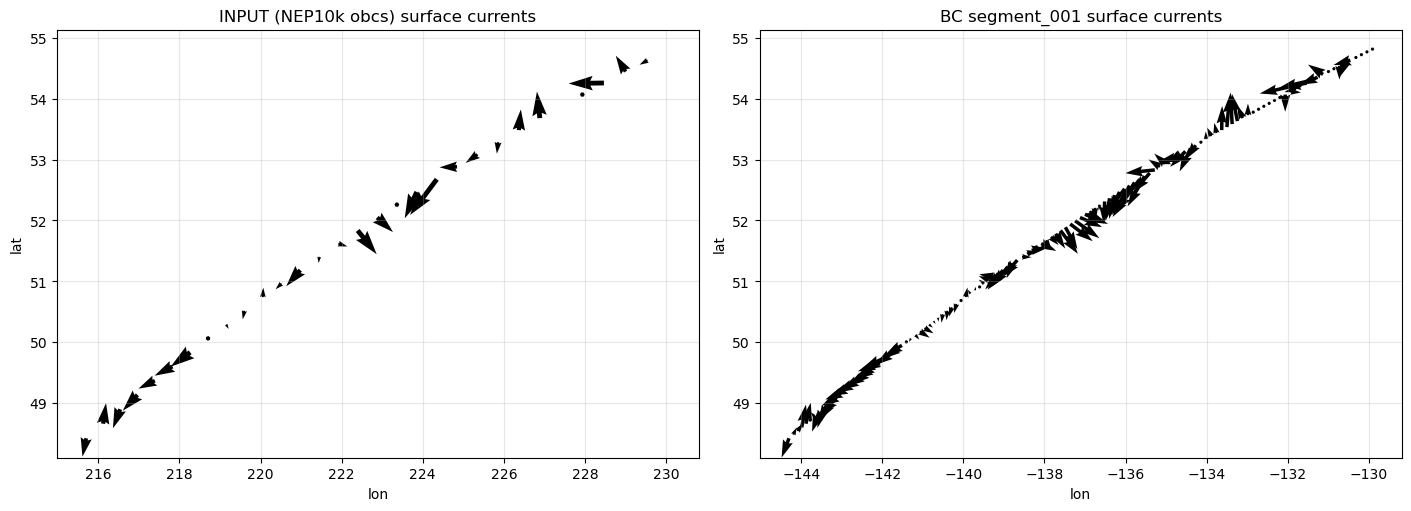

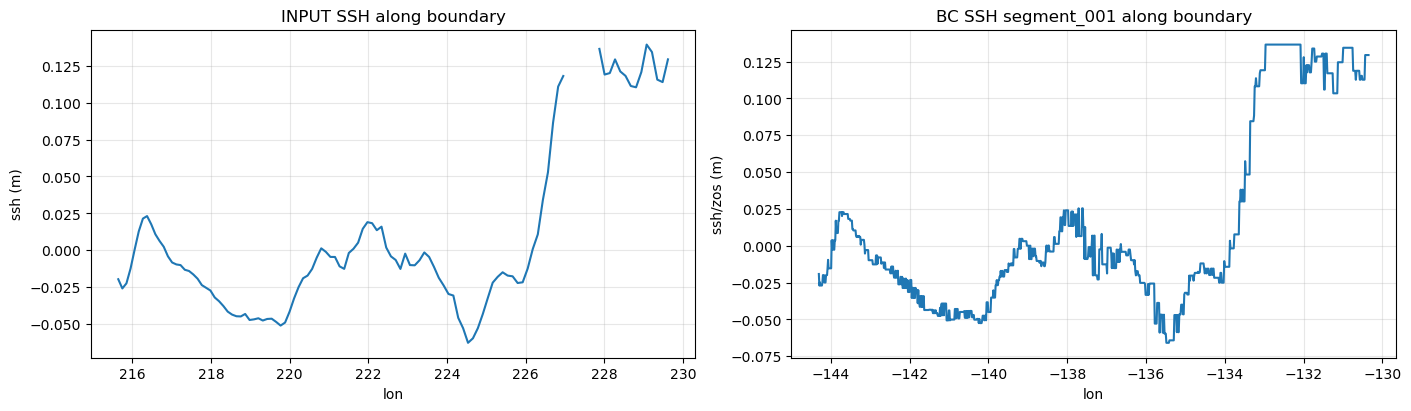

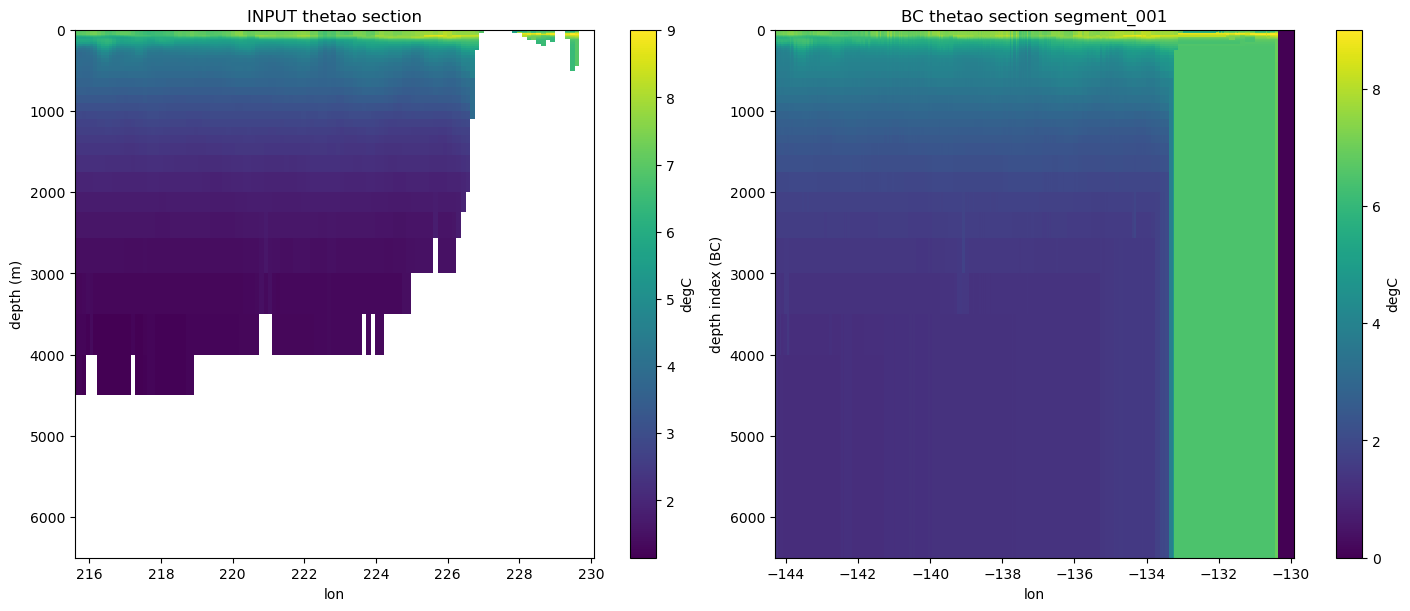

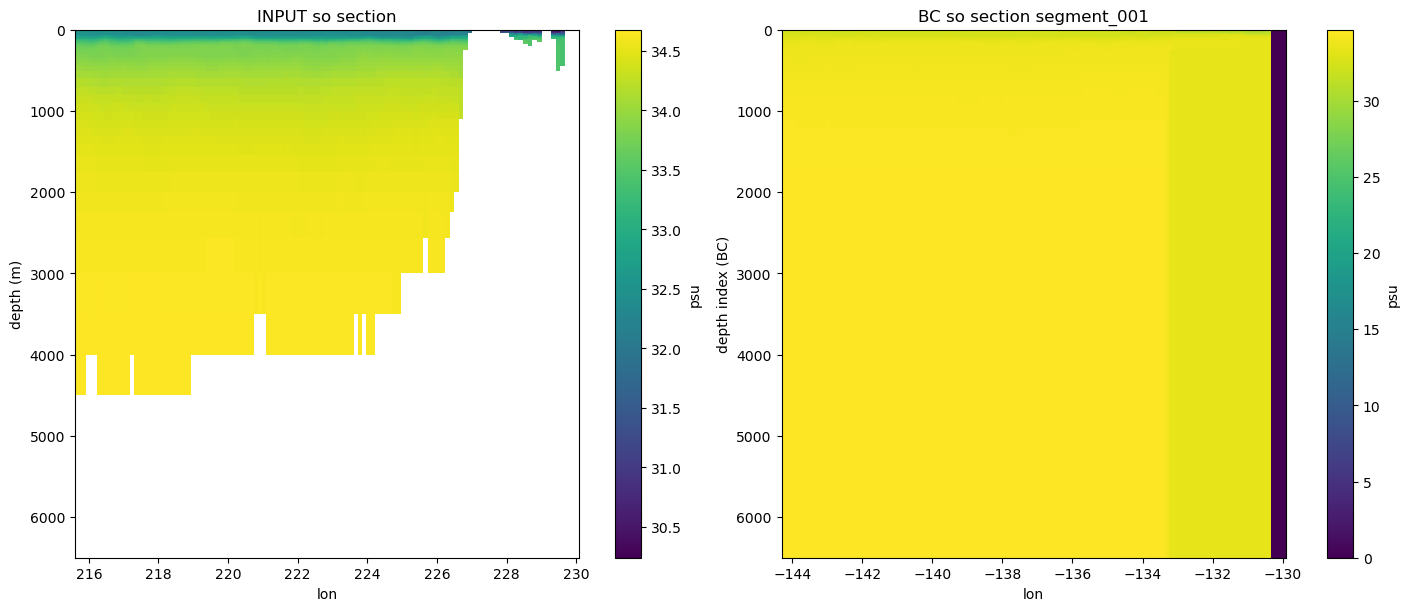

In [8]:
# ---------------------------
# PLOTTING
# ---------------------------
def plot_quiver_side_by_side():
    fig, ax = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

    # INPUT
    step = QUIVER_STEP_INPUT
    ax[0].set_title("INPUT (NEP10k obcs) surface currents")
    ax[0].quiver(
        LONU_in_1d.values[::step], LATU_in_1d.values[::step],
        U_in_1d.values[::step],    V_in_1d.values[::step],
        scale=QUIVER_SCALE, scale_units="inches", angles="xy"
    )
    ax[0].set_xlabel("lon")
    ax[0].set_ylabel("lat")
    ax[0].grid(True, alpha=0.3)

    # BC
    step = QUIVER_STEP_BC
    ax[1].set_title(f"BC segment_{SEG} surface currents")
    ax[1].quiver(
        LON_bc.values[::step], LAT_bc.values[::step],
        U_bc.values[::step],   V_bc.values[::step],
        scale=QUIVER_SCALE, scale_units="inches", angles="xy"
    )
    ax[1].set_xlabel("lon")
    ax[1].set_ylabel("lat")
    ax[1].grid(True, alpha=0.3)

    plt.show()


def plot_ssh_side_by_side():
    fig, ax = plt.subplots(1, 2, figsize=(14, 4), constrained_layout=True)

    ax[0].set_title("INPUT SSH along boundary")
    ax[0].plot(LONT_in_1d.values, SSH_in_1d.values)
    ax[0].set_xlabel("lon")
    ax[0].set_ylabel("ssh (m)")
    ax[0].grid(True, alpha=0.3)

    ax[1].set_title(f"BC SSH segment_{SEG} along boundary")
    ax[1].plot(LON_bc.values, SSH_bc_1d.values)
    ax[1].set_xlabel("lon")
    ax[1].set_ylabel("ssh/zos (m)")
    ax[1].grid(True, alpha=0.3)

    plt.show()


def plot_section_side_by_side(field_in, field_bc, name="T", units=""):
    fig, ax = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

    # INPUT section
    ax[0].set_title(f"INPUT {name} section")
    pm0 = ax[0].pcolormesh(
        LONT_in_1d.values, Z_in,
        field_in.values,
        shading="nearest"
    )
    ax[0].invert_yaxis()
    ax[0].set_xlabel("lon")
    ax[0].set_ylabel("depth (m)")
    cb0 = plt.colorbar(pm0, ax=ax[0])
    cb0.set_label(units)

    # BC section
    ax[1].set_title(f"BC {name} section segment_{SEG}")
    # If you prefer using INPUT Z for the BC axis, replace Z_bc with Z_in (but then shapes must match)
    pm1 = ax[1].pcolormesh(
        LON_bc.values, Z_in,
        field_bc.values,
        shading="nearest"
    )
    ax[1].invert_yaxis()
    ax[1].set_xlabel("lon")
    ax[1].set_ylabel("depth index (BC)")
    cb1 = plt.colorbar(pm1, ax=ax[1])
    cb1.set_label(units)

    plt.show()


# ---------------------------
# run plots
# ---------------------------
# Quiver scaling (tune if arrows too big/small)
QUIVER_SCALE = 0.5  # larger -> shorter arrows

plot_quiver_side_by_side()
plot_ssh_side_by_side()
plot_section_side_by_side(T_in_sec, T_bc_sec, name="thetao", units="degC")
plot_section_side_by_side(S_in_sec, S_bc_sec, name="so", units="psu")

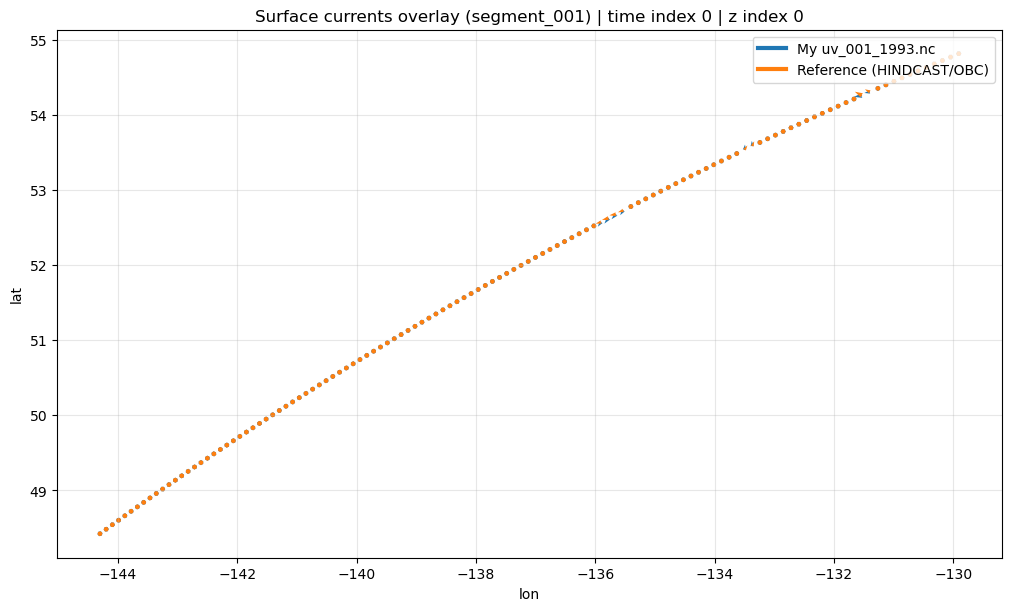

In [9]:
# See versu the old rotated BC 

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

MY_UV_FILE  = "uv_001_1993.nc"  # <-- your BC uv file (the one you generated)
REF_UV_FILE = "/work/Remi.Pages/GOA2p5k/HINDCAST/OBC/uv_001_1993.nc"

SEG = "001"
TIME_INDEX = 0          # compare this time index
Z_INDEX = 0             # surface layer
STEP_MY  = 8            # subsample arrows (tune)
STEP_REF = 8
QUIVER_SCALE = 3.0      # larger -> shorter arrows (tune)

def _find_var(ds, candidates):
    for c in candidates:
        if c in ds.variables:
            return c
    return None

def _to_nan(da):
    if da is None:
        return None
    fv = da.attrs.get("_FillValue", None)
    mv = da.attrs.get("missing_value", None)
    out = da
    for bad in [fv, mv, 1e20, 1.e20, 9.96921e36]:
        if bad is None:
            continue
        out = out.where(out != bad)
    return out

def load_uv_surface(path, seg="001", time_index=0, z_index=0):
    ds = xr.open_dataset(path, decode_times=True)

    # common names in these segment files
    u_name = _find_var(ds, [f"uo_segment_{seg}", f"u_segment_{seg}", "uo_segment_001", "u_segment_001", "uo", "u"])
    v_name = _find_var(ds, [f"vo_segment_{seg}", f"v_segment_{seg}", "vo_segment_001", "v_segment_001", "vo", "v"])
    lon_name = _find_var(ds, [f"lon_segment_{seg}", "lon_segment_001", "lon"])
    lat_name = _find_var(ds, [f"lat_segment_{seg}", "lat_segment_001", "lat"])

    if any(x is None for x in [u_name, v_name, lon_name, lat_name]):
        raise ValueError(
            f"Could not find needed vars in {path}\n"
            f"Found u={u_name}, v={v_name}, lon={lon_name}, lat={lat_name}\n"
            f"Available vars: {list(ds.variables)}"
        )

    U = _to_nan(ds[u_name])
    V = _to_nan(ds[v_name])

    # detect nz dim name (often nz_segment_001)
    nz_dim = None
    for d in U.dims:
        if d.startswith("nz_segment_"):
            nz_dim = d
            break

    # slice time + surface
    if "time" in U.dims:
        U = U.isel(time=time_index)
        V = V.isel(time=time_index)
    if nz_dim is not None:
        U = U.isel({nz_dim: z_index})
        V = V.isel({nz_dim: z_index})

    # squeeze ny=1 etc -> 1D along boundary (nx)
    U = U.squeeze(drop=True)
    V = V.squeeze(drop=True)

    lon = _to_nan(ds[lon_name]).squeeze(drop=True).values
    lat = _to_nan(ds[lat_name]).squeeze(drop=True).values

    return lon, lat, U.values, V.values

# --- load both ---
lon_my,  lat_my,  U_my,  V_my  = load_uv_surface(MY_UV_FILE,  seg=SEG, time_index=TIME_INDEX, z_index=Z_INDEX)
lon_ref, lat_ref, U_ref, V_ref = load_uv_surface(REF_UV_FILE, seg=SEG, time_index=TIME_INDEX, z_index=Z_INDEX)

# --- plot overlay ---
fig, ax = plt.subplots(1, 1, figsize=(10, 6), constrained_layout=True)
ax.set_title(f"Surface currents overlay (segment_{SEG}) | time index {TIME_INDEX} | z index {Z_INDEX}")

# my (blue)
ax.quiver(
    lon_my[::STEP_MY], lat_my[::STEP_MY],
    U_my[::STEP_MY],   V_my[::STEP_MY],
    color="C0", angles="xy",
    scale=QUIVER_SCALE, scale_units="inches"
)

# ref (orange)
ax.quiver(
    lon_ref[::STEP_REF], lat_ref[::STEP_REF],
    U_ref[::STEP_REF],   V_ref[::STEP_REF],
    color="C1", angles="xy",
    scale=QUIVER_SCALE, scale_units="inches"
)

ax.set_xlabel("lon")
ax.set_ylabel("lat")
ax.grid(True, alpha=0.3)

# legend (quiver doesn't auto-legend nicely)
legend_elems = [
    Line2D([0], [0], color="C0", lw=3, label="My uv_001_1993.nc"),
    Line2D([0], [0], color="C1", lw=3, label="Reference (HINDCAST/OBC)"),
]
ax.legend(handles=legend_elems, loc="best")

plt.show()

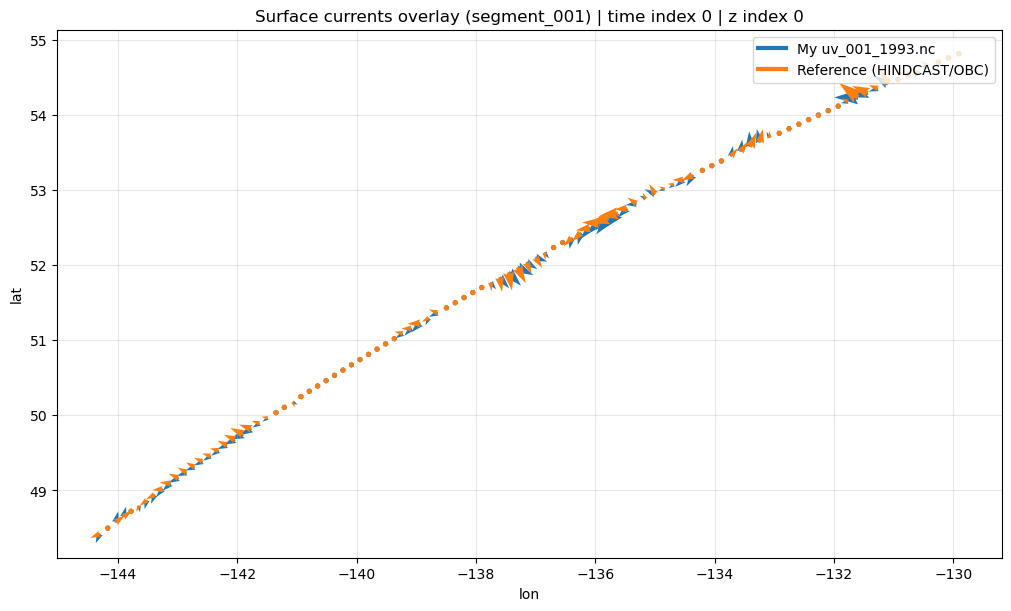

In [10]:
STEP_MY  = 10            # subsample arrows (tune)
STEP_REF = 10
QUIVER_SCALE = 1.0      # larger -> shorter arrows (tune)
# --- load both ---
lon_my,  lat_my,  U_my,  V_my  = load_uv_surface(MY_UV_FILE,  seg=SEG, time_index=TIME_INDEX, z_index=Z_INDEX)
lon_ref, lat_ref, U_ref, V_ref = load_uv_surface(REF_UV_FILE, seg=SEG, time_index=TIME_INDEX, z_index=Z_INDEX)

# --- plot overlay ---
fig, ax = plt.subplots(1, 1, figsize=(10, 6), constrained_layout=True)
ax.set_title(f"Surface currents overlay (segment_{SEG}) | time index {TIME_INDEX} | z index {Z_INDEX}")

# my (blue)
ax.quiver(
    lon_my[::STEP_MY], lat_my[::STEP_MY],
    U_my[::STEP_MY],   V_my[::STEP_MY],
    color="C0", angles="xy",
    scale=QUIVER_SCALE, scale_units="inches"
)

# ref (orange)
ax.quiver(
    lon_ref[::STEP_REF], lat_ref[::STEP_REF],
    U_ref[::STEP_REF],   V_ref[::STEP_REF],
    color="C1", angles="xy",
    scale=QUIVER_SCALE, scale_units="inches"
)

ax.set_xlabel("lon")
ax.set_ylabel("lat")
ax.grid(True, alpha=0.3)

# legend (quiver doesn't auto-legend nicely)
legend_elems = [
    Line2D([0], [0], color="C0", lw=3, label="My uv_001_1993.nc"),
    Line2D([0], [0], color="C1", lw=3, label="Reference (HINDCAST/OBC)"),
]
ax.legend(handles=legend_elems, loc="best")

plt.show()

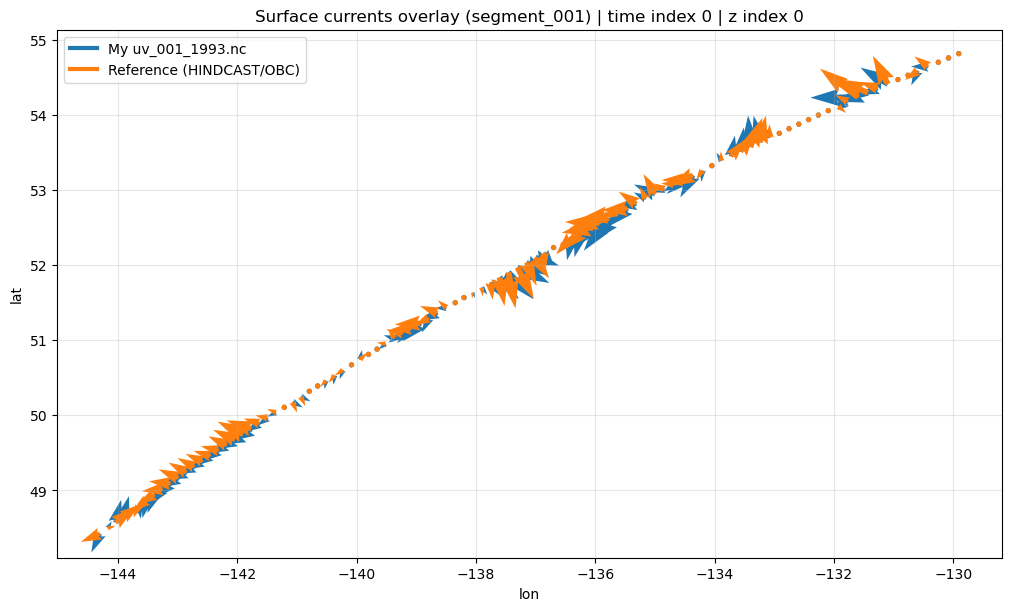

In [13]:
QUIVER_SCALE = 0.5 
# --- plot overlay ---
fig, ax = plt.subplots(1, 1, figsize=(10, 6), constrained_layout=True)
ax.set_title(f"Surface currents overlay (segment_{SEG}) | time index {TIME_INDEX} | z index {Z_INDEX}")

# my (blue)
ax.quiver(
    lon_my[::STEP_MY], lat_my[::STEP_MY],
    U_my[::STEP_MY],   V_my[::STEP_MY],
    color="C0", angles="xy",
    scale=QUIVER_SCALE, scale_units="inches"
)

# ref (orange)
ax.quiver(
    lon_ref[::STEP_REF], lat_ref[::STEP_REF],
    U_ref[::STEP_REF],   V_ref[::STEP_REF],
    color="C1", angles="xy",
    scale=QUIVER_SCALE, scale_units="inches"
)

ax.set_xlabel("lon")
ax.set_ylabel("lat")
ax.grid(True, alpha=0.3)

# legend (quiver doesn't auto-legend nicely)
legend_elems = [
    Line2D([0], [0], color="C0", lw=3, label="My uv_001_1993.nc"),
    Line2D([0], [0], color="C1", lw=3, label="Reference (HINDCAST/OBC)"),
]
ax.legend(handles=legend_elems, loc="upper left")

plt.show()